# Pyro — вероятностный язык программирования для deep learning

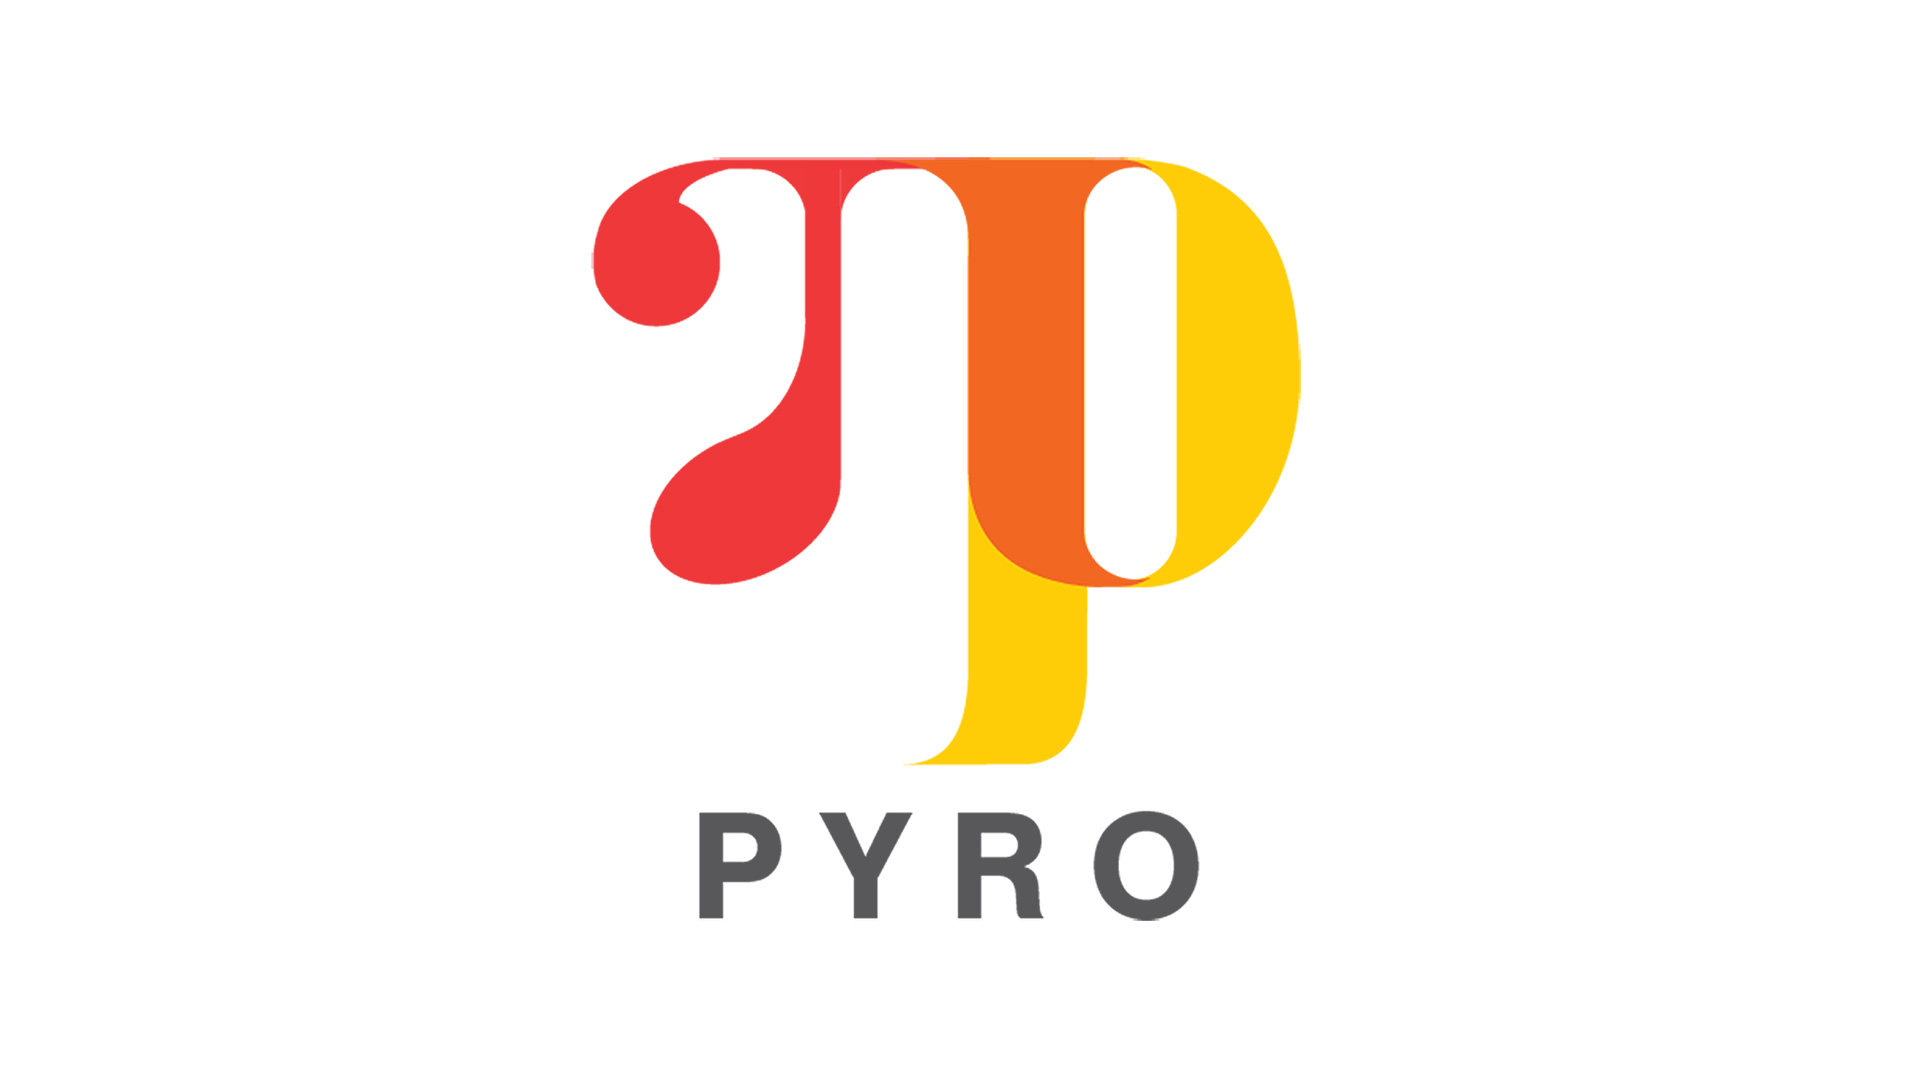

<a href="https://pyro.ai/">Pyro</a> — универсальный вероятностный язык программирования (PPL), написанный на Python, широко поддерживает PyTorch. Pyro обеспечивает гибкое и всестороннее глубокое вероятностное моделирование, объединяет лучшее из современного глубокого обучения и байесовского моделирования. Он был разработан с учетом следующих ключевых принципов:
* **Универсальность:** Pyro может работать с любым вычислимым распределением вероятностей.
* **Масштабируемость:** Pyro легко масштабируется до больших датасетов с минимальными издержками.
* **Компактность:** Pyro реализован с использованием небольшого ядра мощных составных абстракций.
* **Гибкость:**  Pyro легко автоматизируется, но если необходимо, то можно перевести все к полному контролю.

Для установки нужно сначала установить <a href="http://pytorch.org/">PyTorch</a>, затем Pyro:
`pip3 install pyro-ppl`.

Pyro изначально был разработан в **Uber AI** и теперь активно поддерживается участниками сообщества, включая специальную команду в <a href="https://www.broadinstitute.org/">**Broad Institute**</a>. В 2019 году Pyro <a href="https://www.linuxfoundation.org/press-release/2019/02/pyro-probabilistic-programming-language-becomes-newest-lf-deep-learning-project/">стал</a> проектом **Linux Foundation**, нейтральным пространством для совместной работы над программным обеспечением с открытым исходным кодом, открытыми стандартами, открытыми данными и открытым оборудованием.

<a href="https://jmlr.org/papers/volume20/18-403/18-403.pdf">Статья авторов:</a>

    Pyro: Deep Universal Probabilistic Programming. 
    Eli Bingham, Jonathan P. Chen, Martin Jankowiak, Fritz Obermeyer, Neeraj Pradhan, Theofanis Karaletsos, Rohit Singh, Paul Szerlip, Paul Horsfall, Noah D. Goodman; 
    Journal of Machine Learning Research 20 (2019) 1-6
    
Первый публичный релиз: 3 ноября 2017 г., версия 0.1.0

Поддержка PyTorch c версии 0.2.0 (25 апреля 2018)

Последняя версия: 1.9.1 (2 июня 2024)

Данный материал полностью разработан на основе примеров https://pyro.ai/examples/

In [83]:
from pprint import pprint

import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.2)

import torch

import pyro
import pyro.infer
import pyro.optim
import pyro.distributions as dist

pyro.set_rng_seed(42)

from IPython.display import clear_output
from matplotlib.gridspec import GridSpec

# 1. Введение в Pyro-модели

Основной единицей вероятностных программ является случайная функция. Это произвольный код, который сочетает в себе две составляющих:
* детерминированный код;
* примитивные стохастические функции, вызывающие генератор случайных чисел.

### Примитивные стохастические функции

Pyro использует распределения из PyTorch https://pytorch.org/docs/master/distributions.html.

Про них поговорим еще в следующем ноутбуке.

In [ ]:
normal = torch.distributions.Normal(loc=0, scale=1)
x = normal.rsample()

print("Выборка:", x)
print("Логарифм плотности:", normal.log_prob(x))

**Пример**

* Имеются данные о среднесуточной температуре и облачности. 
* Хотим понять зависимость температуры от того, было ли солнечно или облачно. 

Простая стохастическая функция на основе PyTorch:

In [ ]:
def weather():
    cloudy = torch.distributions.Bernoulli(0.3).sample()
    cloudy = "cloudy" if cloudy.item() == 1.0 else "sunny"

    mean_temp = {"cloudy": 55.0, "sunny": 75.0}[cloudy]
    scale_temp = {"cloudy": 10.0, "sunny": 15.0}[cloudy]

    temp = torch.distributions.Normal(mean_temp, scale_temp).rsample()
    return cloudy, temp.item()

In [ ]:
for _ in range(3):
    print(weather())

### Обертки Pyro

Для обработки вероятностных объектов Pyro реализует некоторые обертки над PyTorch-функциями. Для использования основных из них нужно заменить:
* `torch.distributions` на `pyro.distribution`
* вызовы `.sample()` или `.rsample()` на вызовы `pyro.sample`

In [ ]:
# Было:
# normal = torch.distributions.Normal(loc=0, scale=1)
# x = normal.rsample()

x = pyro.sample("my_sample", pyro.distributions.Normal(loc=0, scale=1))

print(x)

Аналогично коду `torch.distributions.Normal().rsample()`, данная Pyro-обертка возвращает семпл из $\mathcal{N}(0, 1)$. Принципиальное отличие заключается в том, что этот семпл **именованнный**. Бэкэнд Pyro использует эти имена для уникальной идентификации функций от семплов и **изменяет их поведение во время выполнения** в зависимости от того, как используется стохастическая функция. Как мы увидим, именно так Pyro может реализовать различные манипуляции, лежащие в основе методов вероятностного вывода.

Модифицируем программу выше

In [ ]:
def weather():
    cloudy = pyro.sample("cloudy", pyro.distributions.Bernoulli(0.3))
    cloudy = "cloudy" if cloudy.item() == 1.0 else "sunny"

    mean_temp = {"cloudy": 55.0, "sunny": 75.0}[cloudy]
    scale_temp = {"cloudy": 10.0, "sunny": 15.0}[cloudy]

    temp = pyro.sample("temp", pyro.distributions.Normal(mean_temp, scale_temp))
    return cloudy, temp.item()


for _ in range(3):
    print(weather())

Теперь `weather()` это не просто недетерминированная python-функция. Она еще и задает **совместное распределение вероятностей** двух именованных переменных `cloudy` и `temp`.

### Универсальность Pyro

Под универсальностью понимается возможность создания
* стохастической рекурсии,
* стохастических функций более высокого порядка,
* случайный поток управления.

Например, на основе функции генерации погоды можем построить функцию продажи мороженного.

In [ ]:
def ice_cream_sales():
    cloudy, temp = weather()

    expected_sales = 200.0 if cloudy == "sunny" and temp > 80.0 else 50.0

    ice_cream = pyro.sample("ice_cream", pyro.distributions.Normal(expected_sales, 10.0))
    return ice_cream

In [ ]:
ice_cream_sales()

Такая модульность достаточно универсальна для написания любой сложной функции, случайность может свободно менять поток управления. 
Например, можно построить рекурсию с недетерминированным завершением с одним условием &mdash; в `pyro.sample` каждый раз будем передавать уникальные имена.

Например, так можно реализовать геометрическое распределение.

In [ ]:
def geometric(p, t=None):
    if t is None:
        t = 0

    x = pyro.sample("x_{}".format(t), pyro.distributions.Bernoulli(p))

    if x.item() == 1:
        return 0
    else:
        return 1 + geometric(p, t + 1)

In [ ]:
for _ in range(3):
    print(geometric(0.2))

Обратите внимание, что имена `x_0`, `x_1`, и т.д., в `geometric()` генерируются динамически и что различные исполнения могут иметь разное количество именованных случайных величин.

Мы также можем легко определять стохастические функции, которые принимают в качестве входных или производят в качестве выходных другие стохастические функции:

In [ ]:
def normal_product(loc, scale):
    z1 = pyro.sample("z1", pyro.distributions.Normal(loc, scale))
    z2 = pyro.sample("z2", pyro.distributions.Normal(loc, scale))
    y = z1 * z2
    return y


def make_normal_normal():
    mu_latent = pyro.sample("mu_latent", pyro.distributions.Normal(0, 1))

    fn = lambda scale: normal_product(mu_latent, scale)
    return fn

In [ ]:
print(make_normal_normal()(1.0))

**Итог:**

Pyro поддерживает произвольный код Python — итерации, рекурсии, функции более высокого порядка и т. д., что в сочетании со случайным потоком управления означает, что стохастические функции в Pyro универсальны, то есть они могут быть использованы для представления любого вычислимого распределения вероятностей.
Это одна из причин, почему Pyro построен поверх PyTorch.

# 2. Стохастический вариационный вывод в Pyro

## 2.1 Условные распределения

Главная особенность вероятностного программирования — способность обусловливать генеративные модели на основе наблюдаемых данных, то есть вычислять условные распределения, и производить оценку скрытых факторов, которые могли бы породить эти данные. В Pyro обусловливание отделено от оценки, что позволяет написать модель один раз и обусловить ее на множество различных данных.

Определим функцию, реализующую следующую схему

$\theta \sim \mathcal{N}(a, 1)$

$X\ |\ \theta \sim \mathcal{N}(\theta, 1/4)$

In [ ]:
def normal_sample(a):
    theta = pyro.sample("theta", dist.Normal(a, 1.0))

    X = pyro.sample("X", dist.Normal(theta, 0.5))

    return theta, X

In [ ]:
normal_sample(5)

С помощью функции `pyro.condition` можно сказать, что некоторая случайная величина наблюдаема, тем самым обусловить по ней все остальные:
* принимает модель и словарь наблюдений
* возвращает новую модель, имеющую те же входные и выходные сигнатуры, но всегда использующую заданные значения в наблюдаемых sample-операторах:

In [ ]:
conditioned_normal_sample = pyro.condition(normal_sample, data={"X": 9.5})

In [ ]:
conditioned_normal_sample(5)

**Внимание!** Пока мы только задали условную модель, но не получили апостериорного распределения. Если посмотреть на генерируемые значения $\theta$, можно увидеть, что пока они еще генерируются из априорного распределения.

Условное распределение тоже можно параметризовать

In [ ]:
def deferred_conditioned_normal_sample(x_value, a_value):
    return pyro.condition(normal_sample, data={"X": x_value})(a_value)

In [ ]:
deferred_conditioned_normal_sample(9.5, 0)

На самом деле у `pyro.sample` есть аргумент `obs`, который полностью аналогичен логике работы `pyro.condition`:

In [ ]:
def normal_sample_obs(a):
    theta = pyro.sample("theta", dist.Normal(a, 1.0))

    X = pyro.sample("X", dist.Normal(theta, 0.5), obs=9.5)

    return theta, X

In [ ]:
normal_sample_obs(5)

Напечатан warning о том, что определено наблюдаемое значение вне методов вывода.

## 2.2 Неслучайные параметры

`pyro.param` — интерфейс для хранения параметров в виде key-value. Как и `pyro.sample`, функция `pyro.param` всегда вызывается с именем в качестве первого аргумента. При первом `pyro.param` вызове с определенным именем он сохраняет свой аргумент в *хранилище параметров*, а затем возвращает это значение.

In [ ]:
a = pyro.param("a", torch.tensor(1.0))
a

После этого, когда он вызывается с этим именем, он *возвращает значение из хранилища параметров независимо от любых других аргументов*. 

In [ ]:
pyro.param("a")

Если мы попробуем переопределить этот параметр, то ничего не выйдет. Pyro это просто проигнорирует

In [ ]:
a = pyro.param("a", torch.tensor(5.0))
a

**Эти параметры Pyro переопределяет сам в процессе совершения вариационного вывода.**

Пользователю предоставляется лишь возможность очистить **все** хранилище параметров:

In [ ]:
pyro.clear_param_store()

Теперь можем заново определить параметр

In [ ]:
a = pyro.param("a", torch.tensor(5.0))
a

**В чем отличие `pyro.param` и `torch.nn.Parameter`?**

`pyro.param` создает **глобальное именованное хранилище параметров**, которым управляет Pyro. Это идеально подходит для вероятностных моделей, которые не обязательно являются `torch.nn.Module`. В свою очередь, `torch.nn.Parameter` привязан к конкретному экземпляру `nn.Module`.

---

Область допустимых значений параметра можно задавать с помощью <a href="https://pytorch.org/docs/master/distributions.html">модуля ограничений</a> из PyTorch. Для этого нужно передать соответствующий `constraint`-объект в `pyro.param`:

In [84]:
from torch.distributions import constraints

scale = pyro.param("scale", torch.tensor(1.0), constraint=constraints.positive)
scale

tensor(1., grad_fn=<AddBackward0>)

In [ ]:
def normal_sample(a):
    scale = pyro.param("scale", torch.tensor(1.0), constraint=constraints.positive)

    theta = pyro.sample("theta", dist.Normal(a, scale))

    X = pyro.sample("X", dist.Normal(theta, 0.5))

    return scale, theta, X

In [ ]:
normal_sample(a)

## 2.3 Вспомним вариационный вывод

**Типы объектов**

Вероятностные модели обычно имеют три различных типа объектов:
* $X$ — наблюдения
* $Y$ — латентные случайные величины
* $\theta$ — неслучайные параметры. 

Они имеют совместную плотность вида
$p_\theta(x, y)=p_\theta(x \mid y)p_\theta(y).$

Предполагаем, что семейство распределений обладает следующими свойствами:
1. Можно просемплировать из $p_\theta(x, y)$ для любого $\theta$.
2. Можно вычислить значения $\log p_\theta(x, y)$ в любой точке.
3. Плотность $p_\theta(x, y)$ дифференцируема по параметрам $\theta$.

*Замечание.* Можем считать $\theta$ случайными параметрами, имеющими вырожденное распределение. В таком случае, объявляя параметрами пару $(Y, \theta)$, сводим задачу к вариационному выводу.


**Соответствие объектов в Pyro**

В Pyro соответствующие типы объектов задаются следующим образом.
1. Наблюдения $X$:
    * `pyro.sample` с аргументом `obs`; 
    * `pyro.condition`


2. Латентные случайные величины $Y$
    * `pyro.sample`

    
3. Неслучайные параметры $\theta$
    * `pyro.param`


**Задача**
1. Найти значение $\theta$, которое максимизирует обоснованность
$$\theta_{\max} = \arg\max\limits_\theta \log p_\theta(x)$$
2. Найти апостериорное распределение $Y$
$$p_{\theta_{max}} (y\mid X) = \frac{p_{\theta_{max}}(X, y)}{\int p_{\theta_{max}}(X, y) dy}.$$

В общем случае это довольно сложная задача:
1. Интеграл по $Y$
2. Максимизация тоже сложная


В теории мы применяли вариационный вывод. Как же реализовать его в Pyro?

### 2.3.1 Guide &mdash; вариационное семейство

Основная идея вариационного вывода заключается в том, что мы вводим параметризованное распределение $$\mathcal{Q} = \left\{\left. \mathsf{Q}_\varphi\:\right|\:\varphi \in \Phi\right\},$$
где $\varphi$ — вариационные параметры, а $\mathsf{Q}_\varphi$ имеет плотность $q_\varphi(y)$. Это распределение (семейство) называется **вариационным распределением** во многих литературных источниках, а в контексте Pyro оно называется **guide**. Он используется в качестве приближения апостериорного распределения.

Вариационный вывод в таком случае производит шаги:
* $\varphi_t = \arg\max\limits_{\varphi \in \Phi} \mathcal{L}(q_\varphi, \theta_t);$
* $\theta_t = \arg\max\limits_{\theta \in \Theta} \mathcal{L}(q_{\varphi_t}, \theta),$

где $\mathcal{L}(q_\varphi, \theta)$ &mdash; вариационная нижняя оценка (ELBO).

*Замечание.* Как правило, каждый из этих шагов обычно распадается на несколько.

Так же, как и модель, guide определяется как стохастическая функция `guide()`, которая
* содержит `pyro.sample` и `pyro.param`, 
* **не содержит наблюдаемых данных**,
* имеет **одинаковую сигнатуру** с `model()`, то есть обе функции должны принимать одинаковые аргументы,
* обязательно должен содержать `pyro.sample` для всех величин, которые были в `model()` в качестве латентных **с теми же именами**, они будут использоваться для матчинга.

Пусть, например, модель содержит *ненаблюдаемую* случайную величину `y_1`. Здесь мы задали для нее **априорное** распределение.

In [ ]:
def model():
    pyro.sample("y_1", ...)

Тогда guide тоже обязательно должен ее содержать, и задавать тем самым для нее **вариационное** распределение.

In [ ]:
def guide():
    pyro.sample("y_1", ...)

Распределения в этих случаях могут быть разными, но **имена должны совпадать точь-в-точь**. Имена являются связующим звеном между `model` и `guide`. Когда Pyro будет выполнять шаг SVI, он будет находить в `guide` случайную величину с именем, например, `'theta'`, генерировать из нее значение, а затем вычислять логарифм плотности этого значения в `model` для случайной величины с тем же именем `'theta'`. Это "сопоставление по именам" — ключевая механика Pyro.

---

Обучение выполняется как задача оптимизации ELBO, где каждая итерация обучения делает шаг в пространстве параметров $(\theta, \varphi)$, который приближает guide ближе к точному апостериорному распределению. Для этого нам нужно определить соответствующую целевую функцию.

### 2.3.2 Класс `SVI`

В Pyro механизм для выполнения вариационного вывода инкапсулирован в класс `SVI`.

Пользователь должен предоставить три объекта:
* модель &mdash; функция, задающая совместное распределение $p_\theta(x, y)$, 
* guide &mdash; функция, задающая вариационное семейство $q_\varphi$
* оптимизатор (обсудим далее). 

Чтобы создать экземпляр класса `SVI` для оптимизации ELBO, нужно написать

In [85]:
from pyro.infer import SVI, Trace_ELBO

svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

Объект класса `SVI` имеет два метода &mdash; `step()` и `evaluate_loss()`, которые инкапсулируют логику вариационного обучения и оценки:
1. Метод `step()` **делает один шаг градиента и возвращает оценку лосса** (т.е. минус ELBO). Аргументы функции `step()` передаются в `model()` и `guide()`.
2. Метод `evaluate_loss()` **возвращает оценку лосса *без* совершения шага** по градиенту. Точно так же, как для `step()`, аргументы функции `evaluate_loss()` передаются в `model()` и `guide()`.

Для случая, когда лосс это ELBO, оба метода также принимают необязательный аргумент `num_particles`:
* количество выборок, используемых для вычисления лосса (в случае `evaluate_loss`)
* количество выборок, используемых для вычисления лосса и его градиента (в случае `step`).

### 2.3.3 Оптимизатор

Напомним, что в Pyro модель и guide могут быть произвольными стохастическими функциями при условии, что
1. `guide` не содержит `pyro.sample` с указанием аргумента `obs`;
2. `model` и `guide` имеют одинаковую сигнатуру.

Это доставляет некоторые проблемы, т.к. различные выполнения `model()` и `guide()` могут иметь совершенно разное поведение. В частности:
* некоторые скрытые случайные величины и параметры появляются только иногда;
* параметры могут создаваться динамически в процессе вывода, иначе говоря, пространство, над которым мы проводим оптимизацию, параметризованное $\theta, \varphi$, может расти и изменяться динамически.

Чтобы поддерживать такое поведение функций, Pyro динамически создает оптимизатор для каждого параметра при первом его появлении во время обучения. Оптимизацию в Pyro реализует класс `optim.PyroOptim`, который в основном представляет собой оболочку вокруг оптимизаторов PyTorch. Класс `PyroOptim` принимает два аргумента: 
* конструктор для оптимизаторов PyTorch `optim_constructor`
* спецификацию аргументов оптимизатора `optim_args`. 

На высоком уровне, в ходе оптимизации, всякий раз, **когда появляется новый параметр**, `optim_constructor` используется для создания экземпляра **нового оптимизатора** данного типа с аргументами, заданными `optim_args`.

На практике скорее всего вы не будете напрямую взаимодействовать с `PyroOptim` непосредственно и вместо этого будете использовать псевдонимы, например, оптимизатор `Adam`.

Существует два способа указать аргументы оптимизатора. 

**Первый способ.**

В простом случае, `optim_args` &mdash; это *фиксированный* словарь, определяющий аргументы, используемые для создания экземпляра оптимизаторов PyTorch для *всех* параметров:

In [86]:
from pyro.optim import Adam

adam_params = {"lr": 0.005, "betas": (0.95, 0.999)}
optimizer = Adam(adam_params)

**Второй способ.**

Для определения аргументов можно получить более тонкий уровень контроля. Пользователь должен указать функицю, которая будет вызвана Pyro при создании оптимизатора для вновь увиденного параметра. Эта вызываемая функция должна иметь следующие аргументы:
* `module_name` — имя Pyro модуля, содержащего параметр, если таковой имеется
* `param_name` — имя параметра в Pyro

Это дает пользователю возможность, например, настраивать скорость обучения для различных параметров. Пример:

In [ ]:
def per_param_callable(module_name, param_name):
    if param_name == "theta":
        return {"lr": 0.010}
    else:
        return {"lr": 0.001}


optimizer = Adam(per_param_callable)

Данная функция определяет скорость обучения 0.01 для pyro-параметра `theta` и скорость обучения 0.001 для всех других параметров.

## 2.4 Пример

**Модель**

$\theta \sim Beta(10, 10)$ — априорная информация.

$(X_1, ..., X_n) \mid \theta \sim Bern(\theta)$ — испытания.

Определим функцию, реализующую данную модель.

In [ ]:
def model(data):
    # определяем гиперпараметры априорного распределения
    alpha_prior = torch.tensor(10.0)
    beta_prior = torch.tensor(10.0)

    # Априорное распределение.
    # Здесь Pyro в SVI подставит семпл из вариационного распределения
    # и посчитает плотность по априорному распределению.
    theta = pyro.sample("theta", dist.Beta(alpha_prior, beta_prior))
    
    # цикл наблюдаемых данных
    for i in range(len(data)):
        # Наблюдаем объект i используя распр. Бернулли.
        # Здесь Pyro в SVI подставит наблюдаемую выборку и посчитает плотность.
        pyro.sample(f"obs_{i}", dist.Bernoulli(theta), obs=data[i])


pyro.render_model(model, model_args=(torch.zeros(5),))

**Guide**

Возьмем
$\mathcal{Q} = \left\{\left. Beta(\alpha, \beta)\:\right|\:\alpha, \beta > 0\right\},$
Заметим, что истинное апостериорное лежит в этом классе


In [ ]:
def guide(data):
    # Параметры вариационного распределения
    alpha = pyro.param("alpha", torch.tensor(20.0), constraint=constraints.positive)
    beta = pyro.param("beta", torch.tensor(20.0), constraint=constraints.positive)

    # Вариационное распределение.
    # Здесь Pyro в SVI сгенерирует семпл из вариационного распределения.
    pyro.sample("theta", dist.Beta(alpha, beta))


pyro.render_model(guide, model_args=(torch.zeros(5),))

Здесь следует отметить несколько моментов:
* Имена ненаблюдаемых случайных величин точно совпадают между `model` и `guide`.
* Функции `model(data)` и `guide(data)` имеют одинаковые аргументы.
* Вариационные параметры имеют тип `torch.tensors`. Флаг `requires_grad` автоматически устанавливается как `True` при использовании `pyro.param`.
* Используем ограничение `constraint=constraints.positive` для параметров `alpha` и `beta`.

Очистим хранилище параметров

In [ ]:
pyro.clear_param_store()

Определим оптимизатор и объект класса `SVI`, реализующий стохастический вариационный вывод

In [ ]:
adam_params = {"lr": 0.0005, "betas": (0.90, 0.999)}
optimizer = pyro.optim.Adam(adam_params)

svi = pyro.infer.SVI(model, guide, optimizer, loss=pyro.infer.Trace_ELBO())

In [ ]:
def callback(trace, it):
    """
    Отрисовка текущего статуса обучения.
    * pi -- оценки вероятностей кластеров на текущей итерации
    * theta -- вероятности белых пикселей на текущей итерации
    * elbo_trace -- зависимость логарифма вариационной нижней оценки от номера итерации
        до текущей итерации включительно
    * optim_elbo -- оптимальная ELBO за все время обучения
    * init -- номер инициализации параметров
    * it -- номер итерации обучения

    Обратите внимание, что использование данной функции может замедлять скорость обучения.
    """

    # Отложенная очистка экрана
    clear_output(wait=True)

    # Объявление фигуры и сетки
    fig = plt.figure(figsize=(10, 10), constrained_layout=True)
    plt.suptitle(f"Итерация {it}")
    gs = GridSpec(3, 2, figure=fig)

    # График вероятностей кластеров
    for i, label in enumerate(trace.keys()):
        if i == 0:
            ax = fig.add_subplot(gs[0, :])
        else:
            ax = fig.add_subplot(gs[(i + 1) // 2, (i + 1) % 2])
        ax.plot(trace[label], lw=2, color="#00CC66")
        ax.set_xlabel("Номер итерации")
        ax.set_title(label)
    sns.set_style("darkgrid")

    plt.tight_layout()
    plt.show()


def visualize_or_not(it, n_iter):
    """
    Функция, которая определяет, визуализировать ли результат данной итерации.

    * it -- номер текущей итерации
    * n_iter -- количество итераций чередования E и M шагов
    """

    return (
        (it < 10)
        or ((it % 10 == 0) and (it < 100))
        or ((it % 100 == 0) and (it < 1000))
        or (it % 1000 == 0)
    )

Все готово для запуска!

А, нет, что-то забыли...

Данные!!!

In [ ]:
n = 20
data = torch.distributions.Bernoulli(0.7).sample(torch.Size([n]))
data

In [ ]:
10 + data.sum(), 10 + n - data.sum()

Запускаем вариационный вывод:

In [ ]:
num_steps = 10001
trace = {"ELBO": [], "alpha": [], "beta": []}

for i in range(num_steps):
    loss = svi.step(data)

    trace["ELBO"].append(-loss)
    trace["alpha"].append(pyro.param("alpha").item())
    trace["beta"].append(pyro.param("beta").item())

    if visualize_or_not(i, num_steps):
        callback(trace, i)

## 2.5 Разбор SVI по шагам

Разберем по шагам, что в себя включает вызов `svi.step(data)`.

**Цель**

Получить несмещенную оценку градиента ELBO по вариационным параметрам $\varphi$ и обновить их
$$\mathcal{L}(\varphi) = \mathsf{E}_q \left[ \log p_\theta(X, Y) - \log q_\varphi(Y)\right]$$

Поскольку мы не можем вычислить математическое ожидание аналитически, мы аппроксимируем его с помощью одного (или нескольких) семплов.

### Шаг 1: Выполнение `guide`

Прежде всего Pyro нужно сгенерировать семпл латентных величин из нашего вариационного распределения
$$\theta^*_1, ..., \theta^*_m \sim q_\varphi$$

**Процесс выполнения `guide`**

1. **Вызов `guide(data)`:** Запускается функция `guide`.<br/><br/>

2. **Получение параметров:** Внутри `guide` встречается `pyro.param('alpha', ...)` и
   `pyro.param('beta', ...)` . 
   
   * Pyro обращается к своему глобальному хранилищу параметров и извлекает их **текущие значения**. 
   
   * Если значение встретилось в первый раз (например, на первой итерации SVI), Pyro поместит в свое глобальное хранилище параметров данный параметр со значением, которое указано в `pyro.param`.<br/><br/>

3. **Сэмплирование:** Выполняется `pyro.sample('theta', dist.Beta(alpha, beta))`.
   
   * Из распределения Beta с текущими параметрами `alpha` и `beta` генерируется одно конкретное значение, назовем его $\theta^*$.<br/><br/>

4. **Запись в `trace`:** Pyro не просто возвращает $\theta^*$. Специальный трассировщик, записывает все, что произошло:
   - Имя случайной величины: `'theta'`.
   - Использованное распределение: `dist.Beta(alpha, beta)`.
   - Сгенерированное значение: $\theta^*$.

   **Важно:** Вычисляется и сохраняется логарифм плотности этого события:
   $\log q_\varphi(\theta^*)$.

На этом работа с `guide` завершена. У нас есть trace его выполнения и конкретный семпл латентной величины $\theta^*$.

In [ ]:
def guide(data):
    # Параметры вариационного распределения
    alpha = pyro.param("alpha", torch.tensor(20.0), constraint=constraints.positive)
    beta = pyro.param("beta", torch.tensor(20.0), constraint=constraints.positive)

    # Вариационное распределение.
    # Здесь Pyro в SVI сгенерирует семпл из вариационного распределения.
    pyro.sample("theta", dist.Beta(alpha, beta))

### Шаг 2: Выполнение `model` 

Теперь Pyro нужно оценить, насколько "правдоподобен" сгенерированный семпл $\theta^*$ с точки зрения нашей основной модели $p_\theta(X)$.

1. **Вызов `model(data)`:** Запускается функция `model`.<br/><br/>

2. **Переиспользование:** Выполнение доходит до `pyro.sample('theta', dist.Beta(alpha_prior, beta_prior))`.
   - Трассировщик видит имя `'theta'`. Здесь он проверяет, есть ли уже значение для `'theta'` из `guide`? Да, есть — это $\theta^*$.
   - **Вместо нового семплирования**, "подставляет" (`replays`) уже существующее значение $\theta^*$ в этом месте. Таким образом, и `guide`, и `model` оперируют **одним и тем же** значением латентной величины.

   - **Важно:** Вычисляется и сохраняется в trace логарифм плотности этого события, но уже по **априорному** распределению из модели: $\log q_0(\theta^*)$.<br/><br/>

3. **Обработка наблюдений:** Далее `model` в цикле доходит до `pyro.sample(f'obs_{i}', 
   dist.Bernoulli(theta), obs=data[i])`.
   - Здесь `theta` $=\theta^*$.
   - Поскольку указан аргумент `obs=data[i]`, семплирования не происходит.
   - Вместо этого вычисляется и записывается в trace логарифм правдоподобия наблюдаемых данных при данном значении $\theta^*$: $\log p_{\theta^*}(X_i)$.

In [ ]:
def model(data):
    # определяем гиперпараметры априорного распределения
    alpha_prior = torch.tensor(10.0)
    beta_prior = torch.tensor(10.0)

    # Априорное распределение.
    # Здесь Pyro в SVI подставит семпл из вариационного распределения
    # и посчитает плотность по априорному распределению.
    theta = pyro.sample("theta", dist.Beta(alpha_prior, beta_prior))

    # цикл наблюдаемых данных
    for i in range(len(data)):
        # Наблюдаем объект i используя распр. Бернулли.
        # Здесь Pyro в SVI подставит наблюдаемую выборку и посчитает плотность.
        pyro.sample(f"obs_{i}", dist.Bernoulli(theta), obs=data[i])


pyro.render_model(model, model_args=(torch.zeros(5),))

### Шаг 3: Вычисление оценки ELBO

После выполнения `model` и `guide` у Pyro есть два "следа" (trace) со всеми необходимыми логарифмами плотностей. Теперь он может собрать из них оценку ELBO для нашего семпла $\theta^*$:

* $log p_\theta(X)$ аппроксимируется как: $$\log q(\theta^*) + \sum_{i=1}^n \log p_{\theta^*}(X_i),$$ где все логарифмы из trace.<br/><br/>

* $\log q_\varphi(Y)$ аппроксимируется как: $$\log q_\varphi(\theta^*).$$<br/><br/>

Оценка ELBO равна
$$\mathcal{L}(\varphi) = \mathsf{E}_q \left[ \log p(X, \theta) - \log q_\varphi(\theta)\right] \approx \log q(\theta^*) + \sum_{i=1}^n \log p_{\theta^*}(X_i) - \log q_\varphi(\theta^*).$$

В случае нескольких семплов $\theta^*_1, ..., \theta^*_m$ формула обобщается усреднением по этим семплам.<br/><br/>

Функция потерь `loss` $= -ELBO$.

### Шаг 4: Расчет градиентов и обновление параметров

1. **Автоматическое дифференцирование**

    Вся цепочка вычислений от параметров $alpha$, $beta$ до итогового `loss` была построена с помощью дифференцируемых операций PyTorch. Pyro (через PyTorch) вызывает `.backward()` на скаляре `loss`. Autograd вычисляет градиенты $\frac{\partial\:\text{loss}}{\partial \alpha}$ и $\frac{\partial\:\text{loss}}{\partial \beta}$.<br/><br/>

2. **Шаг оптимизатора:** Вызывается `optimizer.step()`. 

    Оптимизатор (будь то `pyro.optim` или `torch.optim`) берет вычисленные градиенты и обновляет значения $alpha$ и $beta$ в хранилище параметров согласно своему методу оптимизации (например, `Adam`).<br/><br/>

3. **Очистка градиентов:** Оптимизатор вызывает `zero_grad()` для подготовки к следующей итерации.

---

Один шаг `svi.step` завершен, и наши вариационные параметры стали немного лучше. 

## 2.6 Обёртка ELBO для работы в PyTorch-стиле

В новых версиях Pyro класс `Trace_ELBO` (и ему подобные) теперь реализуют метод `__call__`, который позволяет «привязывать» пару (модель, guide) и использовать их как обычный модуль PyTorch. Такие модули имеют название `ELBOModule`.

Рассмотрим пример. Для начала очистим хранилище параметров Pyro, которое у нас осталось с предыдущего эксперимента

In [ ]:
pyro.clear_param_store()

Раньше (до Pyro 1.9) Pyro-параметры всегда были **глобальными**, как бы "в воздухе". Это вызывало:

* путаницу при создании нескольких моделей;

* невозможность обучать несколько Pyro-моделей в одном процессе (они конфликтовали по именам параметров);

* несовместимость с API `torch.nn.Module`.

Теперь появился новый режим `module_local_params=True`, который переводит Pyro из традиционного для Руго “глобального режима” параметров в модульный (объектно-ориентированный) режим, где каждый модуль (`PyroModule`) хранит свои параметры внутри себя — как обычный `nn.Module`. Pyro-параметры становятся модульными и изолированными, как в обычном PyTorch.

In [ ]:
pyro.settings.set(module_local_params=True)

Привязываем модель и guide к ELBO

In [ ]:
elbo_mod = pyro.infer.Trace_ELBO()(model, guide)
type(elbo_mod)

Теперь `elbo_mod` — это уже callable-объект, который при вызове `elbo_mod(*args, **kwargs)` возвращает оценку ELBO (и, в зависимости от режима, выполняет шаги градиента). Это позволяет «упростить» код, интегрируя его с обычной инфраструктурой обучения в PyTorch.

Такой интерфейс используется для лучшей совместимости с PyTorch-модулями и экосистемой обучения (например, PyTorch Lightning, оптимизаторы, scheduler’ы и др.). При этом важно помнить:

* Параметры, используемые в модели и guide, всё ещё хранятся в глобальном параметр-хранилище `pyro.get_param_store()`.

* Новый интерфейс может вести себя неожиданно при сочетании с PyroModule и глобальным параметр-хранилищем, поэтому в документации рекомендуют `pyro.settings.set(module_local_params=True)` при использовании данного интерфейса 

Объявляем оптимизатор, в который закинем все параметры модуля

In [ ]:
# Делаем фиктивный проход, чтобы зарегистрировать параметры
_ = elbo_mod(data)

# Извлекаем параметры как список
params = [pyro.param(name).unconstrained() for name in pyro.get_param_store().keys()]

# Теперь можно использовать обычный torch.optim.Adam
optimizer = torch.optim.Adam(params, lr=0.0005, betas=(0.90, 0.999))

Теперь можем использовать стандартный пайплайн обучения моделей PyTorch

In [ ]:
num_steps = 10001
trace = {"ELBO": [], "alpha": [], "beta": []}

for i in range(num_steps):
    optimizer.zero_grad()

    loss = elbo_mod(data)  # вызывает model и guide
    loss.backward()  # считаем градиенты
    optimizer.step()  # шаг оптимизатора

    trace["ELBO"].append(-loss.item())
    trace["alpha"].append(pyro.param("alpha").item())
    trace["beta"].append(pyro.param("beta").item())

    if visualize_or_not(i, num_steps):
        callback(trace, i)

## Задание
Установим автоматическую валидацию параметров

In [191]:
pyro.enable_validation(True)


**1.** Рассмотрите следующую модель и постройте для нее вариационный вывод.

$X|\theta \sim \mathcal{N}(\theta_1, \theta_2^{-1})$

$\theta_1 \sim \mathcal{N}(a_0, \sigma_0^2)$

$\theta_2 \sim \Gamma(\alpha_0, \beta_0)$

Распределения в семействе $\mathcal{Q}$ факторизуются на независимые нормальные и гамма распределения.

Решение оформите в виде класса:

In [192]:
from torch.distributions import constraints

In [204]:
def model(X):
    alpha = torch.tensor(1.0)
    beta = torch.tensor(1.0)
    mu_log_theta2 = torch.tensor(0.0)
    sigma_log_theta2 = torch.tensor(1.0)

    theta1 = pyro.sample("theta1", dist.Gamma(alpha, beta))
    log_theta2 = pyro.sample("log_theta2", dist.Normal(mu_log_theta2, sigma_log_theta2))
    theta2 = torch.exp(log_theta2)  # now theta2 > 0

    for i in range(len(X)):
        scale = 1.0 / torch.sqrt(theta2)  # if theta2 is PRECISION
        # OR: scale = theta2  # if theta2 is STD DEV (simpler!)
        pyro.sample(f"obs_{i}", dist.Normal(theta1, scale), obs=X[i])


def guide(X):
    alpha_q = pyro.param("alpha_q", torch.tensor(1.0), constraint=constraints.positive)
    beta_q = pyro.param("beta_q", torch.tensor(1.0), constraint=constraints.positive)
    mu_q = pyro.param("mu_q", torch.tensor(0.0))
    sigma_q = pyro.param("sigma_q", torch.tensor(1.0), constraint=constraints.positive)

    pyro.sample("theta1", dist.Gamma(alpha_q, beta_q))
    pyro.sample("log_theta2", dist.Normal(mu_q, sigma_q))

In [205]:
theta_1_true = 1
theta_2_true = 0.5

X = torch.distributions.Normal(loc=theta_1_true, scale=1/theta_2_true).sample((20,))
X

tensor([ 1.1754,  3.1876,  0.7646,  0.4027,  4.8982,  0.1496,  0.2494,  3.8934,
        -0.5743,  5.9984,  0.3961,  1.4414,  1.4233,  3.4543, -0.1446,  0.6586,
         0.0826,  0.6912,  0.5737, -0.7760])

In [206]:
pyro.clear_param_store()

In [207]:
adam_params = {"lr": 0.0005, "betas": (0.90, 0.999)}
optimizer = pyro.optim.Adam(adam_params)

svi = pyro.infer.SVI(model, guide, optimizer, loss=pyro.infer.Trace_ELBO())

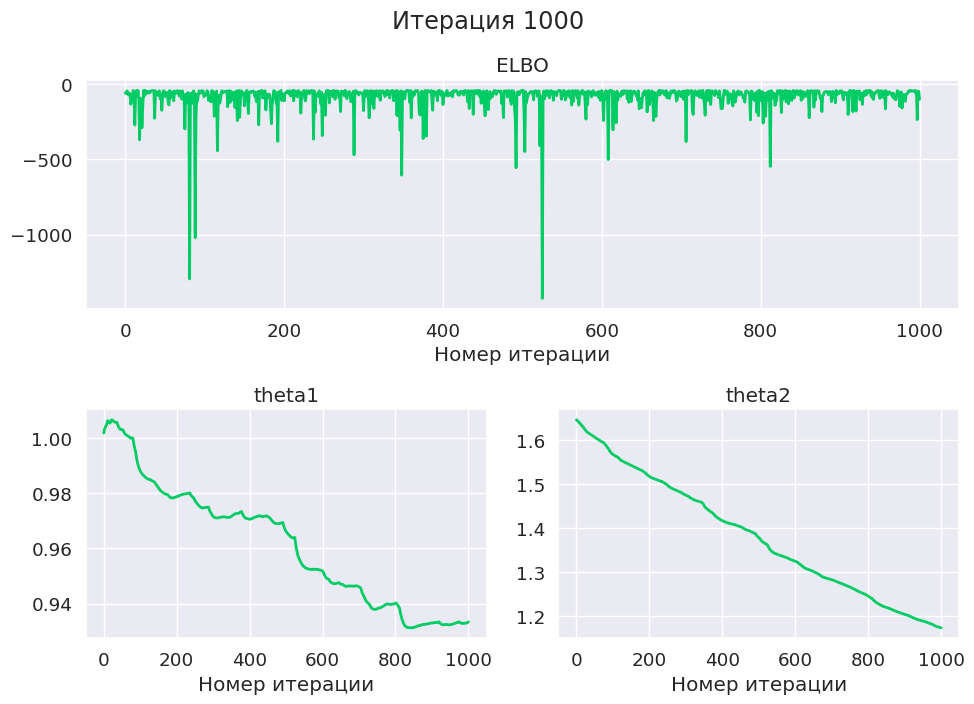

In [209]:
num_steps = 1001
trace = {"ELBO": [], "theta1": [], "theta2": []}

for i in range(num_steps):
    loss = svi.step(X)
    trace["ELBO"].append(-loss)
    
    # Get variational parameters
    alpha_q = pyro.param("alpha_q").item()
    beta_q = pyro.param("beta_q").item()
    mu_q = pyro.param("mu_q").item()
    sigma_q = pyro.param("sigma_q").item()
    
    # Compute posterior means
    E_theta1 = alpha_q / beta_q
    E_theta2 = torch.exp(torch.tensor(mu_q + sigma_q**2 / 2)).item()
    
    trace["theta1"].append(E_theta1)
    trace["theta2"].append(E_theta2)

    if visualize_or_not(i, num_steps):
        callback(trace, i)

**2.** Рассмотрите модель 

$X|\theta \sim \mathcal{N}(\theta_1, \theta_2^{-1})$

$(\theta_1, \theta_2)$ имеет априорное гамма-нормальное распределение

Распределения в семействе $\mathcal{Q}$ факторизуются на независимые нормальные и гамма распределения.

Сравните апостериорное распределение с полученным в результате SVI.

**3.** Рассмотрите модель 

$X|\theta \sim \mathcal{N}(\theta_1, \theta_2^{-1})$

$(\theta_1, \theta_2)$ имеет априорное гамма-нормальное распределение

Распределения в семействе $\mathcal{Q}$ — гамма-нормальные распределения.

Сравните апостериорное распределение с полученным в результате SVI.

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока